In [1]:
# ==============================================================
# Libraries
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import treecorr

In [2]:
# ==============================================================
# Load full catalog (no artificial split)
# ==============================================================

def load_frb_catalog(filepath):
    df = pd.read_csv(filepath)
    df = df[["RA", "DEC"]].dropna()

    valid = (df["RA"] >= 0) & (df["RA"] < 360) & \
            (df["DEC"] >= -90) & (df["DEC"] <= 90)

    return df[valid].reset_index(drop=True)

# ==============================================================
# Footprint-aware randoms (data-driven)
# ==============================================================

def generate_random_from_data(df, n_random, seed=None):
    """
    Generate random catalog that follows the angular footprint
    of the data using empirical DEC resampling.
    """
    rng = np.random.default_rng(seed)

    ra = 360.0 * rng.random(n_random)
    dec = rng.choice(df["DEC"].values, size=n_random, replace=True)

    return pd.DataFrame({"RA": ra, "DEC": dec})

# ==============================================================
# 2pACF
# ==============================================================

def get_2pacf(df_data, df_rand, min_sep=1.0, max_sep=180.0, nbins=15):

    cat = treecorr.Catalog(ra=df_data["RA"], dec=df_data["DEC"],
                           ra_units="deg", dec_units="deg")

    rnd = treecorr.Catalog(ra=df_rand["RA"], dec=df_rand["DEC"],
                           ra_units="deg", dec_units="deg")

    config = dict(min_sep=min_sep, max_sep=max_sep,
                  nbins=nbins, sep_units="deg")

    nn = treecorr.NNCorrelation(**config)
    rr = treecorr.NNCorrelation(**config)
    dr = treecorr.NNCorrelation(**config)

    nn.process(cat)
    rr.process(rnd)
    dr.process(cat, rnd)

    nn.calculateXi(rr=rr, dr=dr)

    log_edges = np.linspace(np.log(min_sep), np.log(max_sep), nbins + 1)
    theta = np.exp(0.5 * (log_edges[:-1] + log_edges[1:]))

    return theta, nn.xi

# ==============================================================
# Absolute Sum
# ==============================================================

def get_abs_sum(theta, w, bins):
    vals = []
    for i in range(len(bins) - 1):
        mask = (theta >= bins[i]) & (theta < bins[i+1])
        vals.append(np.abs(np.mean(w[mask])) if np.any(mask) else 0.0)
    return np.array(vals)

In [3]:
# ==============================================================
# Load data
# ==============================================================

CATALOG_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/SkyPosition.csv"

df_data = load_frb_catalog(CATALOG_PATH)

N_OBS = len(df_data)
N_RAND_FACTOR = 20
N_RAND = N_OBS * N_RAND_FACTOR

print(f"Loaded {N_OBS} FRBs")

# ==============================================================
# Observed signal
# ==============================================================

df_rand = generate_random_from_data(df_data, N_RAND, seed=42)

theta_obs, w_obs = get_2pacf(df_data, df_rand)

COARSE_BINS = np.arange(0, 181, 30)
CENTERS = 0.5*(COARSE_BINS[:-1] + COARSE_BINS[1:])

abs_obs = get_abs_sum(theta_obs, w_obs, COARSE_BINS)

# ==============================================================
# H0 benchmark (same footprint!)
# ==============================================================

N_REAL = 200

w_h0 = []
abs_h0 = []

for i in tqdm(range(N_REAL), desc="H0"):

    d_iso = generate_random_from_data(df_data, N_OBS, seed=i)
    r_iso = generate_random_from_data(df_data, N_RAND, seed=i+1000)

    _, w = get_2pacf(d_iso, r_iso)

    w_h0.append(w)
    abs_h0.append(get_abs_sum(theta_obs, w, COARSE_BINS))

w_h0 = np.array(w_h0)
abs_h0 = np.array(abs_h0)

# ==============================================================
# Stats
# ==============================================================

w_med = np.median(w_h0, axis=0)
w_std = np.std(w_h0, axis=0)

abs_med = np.median(abs_h0, axis=0)
abs_std = np.std(abs_h0, axis=0)

Loaded 4489 FRBs


H0:   0%|          | 0/200 [00:00<?, ?it/s]

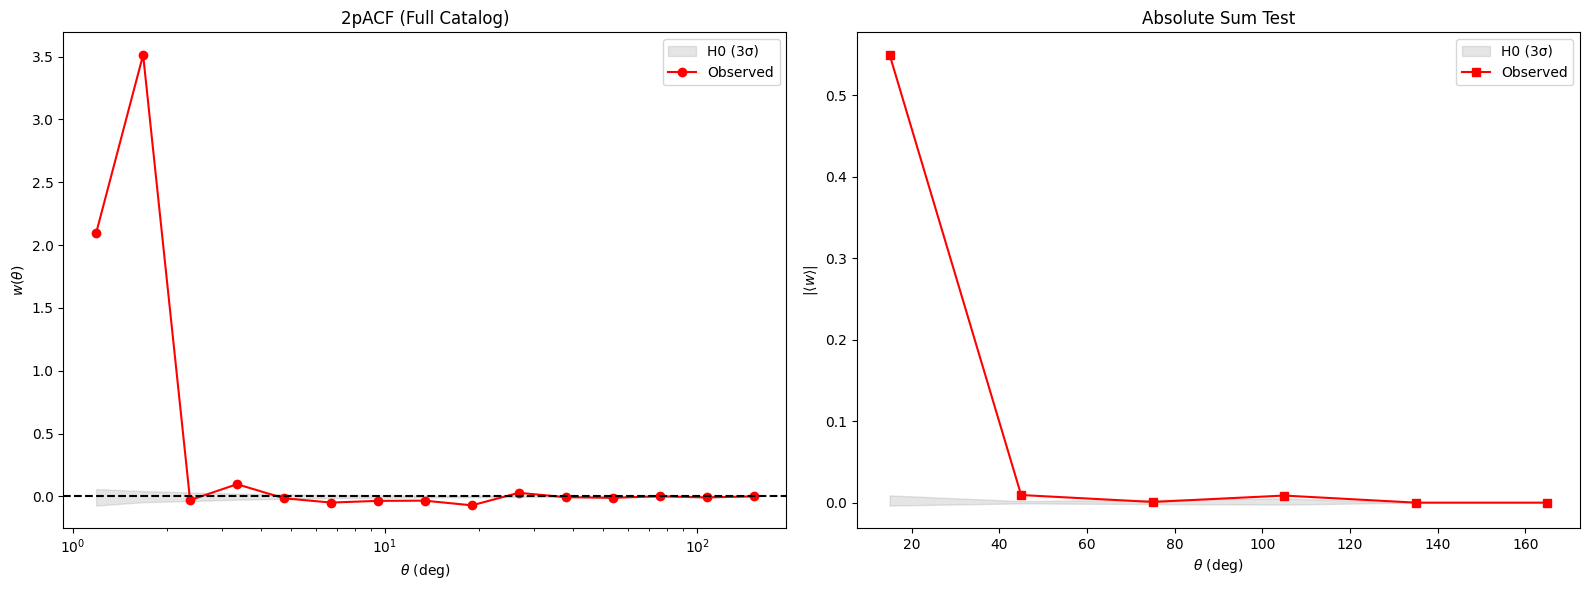

In [5]:
# ==============================================================
# Plot
# ==============================================================

fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].fill_between(theta_obs,
                   w_med - 3*w_std,
                   w_med + 3*w_std,
                   color='gray', alpha=0.2, label='H0 (3σ)')

ax[0].plot(theta_obs, w_obs, 'o-', color='red', label='Observed')

ax[0].axhline(0, color='black', ls='--')
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$\theta$ (deg)')
ax[0].set_ylabel(r'$w(\theta)$')
ax[0].set_title('2pACF (Full Catalog)')
ax[0].legend()

ax[1].fill_between(CENTERS,
                   abs_med - 3*abs_std,
                   abs_med + 3*abs_std,
                   color='gray', alpha=0.2, label='H0 (3σ)')

ax[1].plot(CENTERS, abs_obs, 's-', color='red', label='Observed')

ax[1].set_xlabel(r'$\theta$ (deg)')
ax[1].set_ylabel(r'$|\langle w \rangle|$')
ax[1].set_title('Absolute Sum Test')
ax[1].legend()

plt.tight_layout()
plt.savefig("2pACF_FRB_analysis_15cats_0.png", dpi=300, bbox_inches='tight')
plt.show()